# Exercises 3 - Advanced Multiclass Classification with Keras

- Id: 22302421
- Full name: Nguyễn Phúc Minh Châu

This notebook is an **advanced practice exercise** on **multiclass classification using Keras**.

Dataset: Wine Dataset (3 classes)

Students are required to **design, train, and evaluate** a neural network following the given constraints.


## General Requirements

You must complete all TODO sections.

Do NOT change the dataset.

Use only Keras (TensorFlow backend).

Your implementation must strictly follow the model configuration requirements below.


In [1]:
# Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1778211911.578735  101684 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778211911.640900  101684 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778211913.024947  101684 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Step 1: Load Dataset

Load the Wine dataset from scikit-learn.

Requirements:
- X contains input features
- y contains class labels (3 classes)


In [2]:
# Load Wine dataset (DO NOT MODIFY)
data = load_wine()
X = data.data
y = data.target

print("Input shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Input shape: (178, 13)
Number of classes: 3


## Step 2: Data Preprocessing

Requirements:
- Split data into training and test sets (test size = 20%)
- Apply feature normalization using StandardScaler
- Convert labels to one-hot encoding


In [3]:
# TODO: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# TODO: One-hot encoding for labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Step 3: Model Design (IMPORTANT)

You must build a neural network that satisfies ALL conditions below:

Model Requirements:
1. Input layer must match the feature dimension of the dataset.
2. Hidden Layer 1:
   - Dense layer with 64 neurons
   - ReLU activation
3. Dropout layer with rate = 0.3
4. Hidden Layer 2:
   - Dense layer with 32 neurons
   - ReLU activation
5. Output Layer:
   - Dense layer with number of neurons equal to number of classes
   - Softmax activation


In [4]:
# TODO: Build the model using Sequential API
model = Sequential()

# TODO: Add Dense(64, activation='relu', input_shape=(... ,))
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# TODO: Add Dropout(0.3)
model.add(Dropout(0.3))

# TODO: Add Dense(32, activation='relu')
model.add(Dense(32, activation='relu'))

# TODO: Add output Dense layer with softmax activation
model.add(Dense(y_train.shape[1], activation='softmax'))

/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778211923.948897  101684 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Step 4: Compile the Model

Compile Requirements:
- Optimizer: Adam
- Loss function: categorical_crossentropy
- Metric: accuracy


In [5]:
# TODO: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Step 5: Train the Model

Training Requirements:
- Epochs: 100
- Batch size: 16
- Validation split: 0.2
- Use EarlyStopping with:
  - monitor = 'val_loss'
  - patience = 10
  - restore_best_weights = True


In [6]:
# TODO: Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# TODO: Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=16, callbacks=[early_stopping], verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.4425 - loss: 1.0902 - val_accuracy: 0.7586 - val_loss: 0.9328
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6726 - loss: 0.9397 - val_accuracy: 0.8621 - val_loss: 0.7816
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7699 - loss: 0.7961 - val_accuracy: 0.8621 - val_loss: 0.6491
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8673 - loss: 0.6445 - val_accuracy: 0.8621 - val_loss: 0.5417
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8850 - loss: 0.5404 - val_accuracy: 0.8966 - val_loss: 0.4553
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9558 - loss: 0.4264 - val_accuracy: 0.8966 - val_loss: 0.3842
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9558 - loss: 0.3912 - val_accuracy: 0.8966 - val_loss: 0.3302
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9558 - loss: 0.3253 - val_accuracy: 0.8966 - val_loss:

## Step 6: Training Visualization

Plot the following graphs:
- Training vs Validation Loss
- Training vs Validation Accuracy


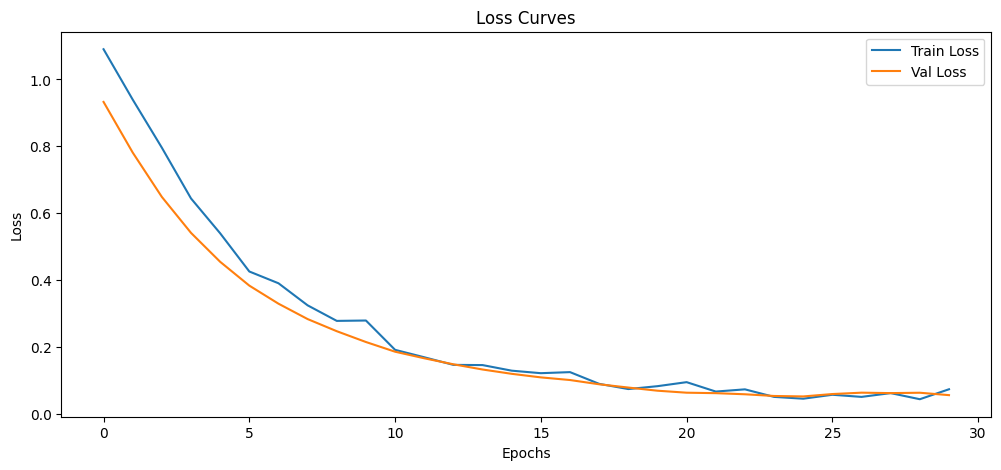

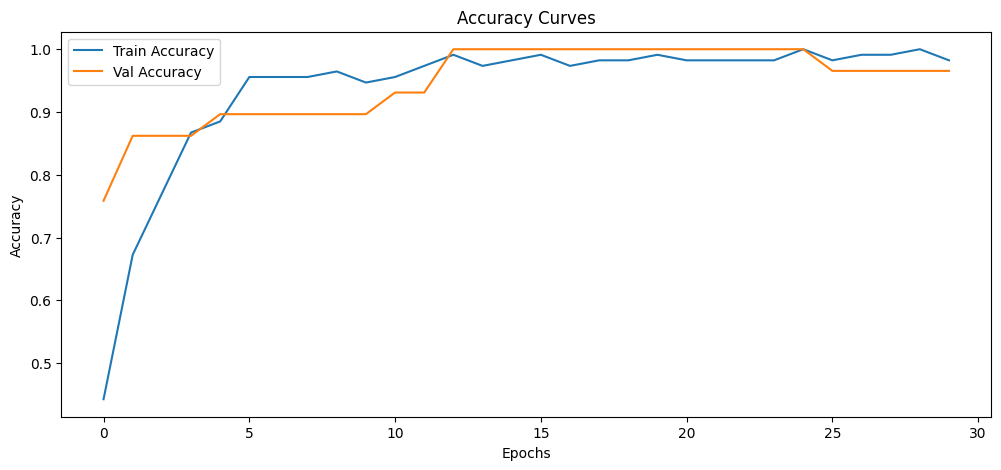

In [8]:
# TODO: Plot loss curves
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# TODO: Plot accuracy curves
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Step 7: Model Evaluation

Evaluation Requirements:
- Predict class labels on the test set
- Compute Confusion Matrix
- Visualize Confusion Matrix using heatmap
- Print Classification Report


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


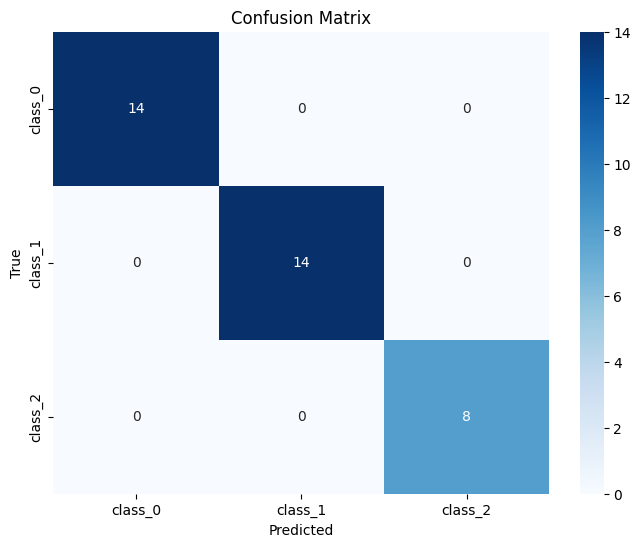

Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [9]:
# TODO: Predict probabilities on test data
y_pred_prob = model.predict(X_test)

# TODO: Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# TODO: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# TODO: Plot Confusion Matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# TODO: Classification Report
report = classification_report(y_true, y_pred, target_names=data.target_names)
print("Classification Report:\n", report)

## Conceptual Questions

**Question 1: Why is Dropout useful in deep neural networks?**
    
Dropout is a regularization technique that helps prevent overfitting in deep neural networks. By randomly "dropping out" a fraction of the neurons during training, it forces the network to learn more robust features that are not reliant on specific neurons. This leads to better generalization on unseen data.

**Question 2: What problem does EarlyStopping help to solve?**
    
EarlyStopping helps to solve the problem of overfitting. It monitors a specified metric (like validation loss) during training and stops the training process if the metric does not improve for a certain number of epochs (patience). This prevents the model from continuing to train and potentially overfitting to the training data.

**Question 3: Why is Softmax required for multiclass classification?**
    
Softmax is required for multiclass classification because it converts the raw output scores (logits) from the final layer of the neural network into probabilities that sum to 1. Each output node corresponds to a class, and the softmax function ensures that the output can be interpreted as the probability of each class being the correct one.

**Question 4: What happens if we use Mean Squared Error instead of categorical_crossentropy?**
    
Using Mean Squared Error (MSE) instead of categorical_crossentropy for a multiclass classification problem can lead to suboptimal performance. MSE is more suitable for regression tasks, and it does not take into account the probabilistic nature of classification. Categorical crossentropy, on the other hand, is designed to measure the difference between the predicted probability distribution and the true distribution (one-hot encoded labels), making it more appropriate for classification tasks.